# Vanilla Extended Ptychographic Iterative Engine (ePIE)

A basic python implementation of the seminal paper by Rodenburg *et al*:

**Rodenburg, J. M., & Faulkner, H. M. L.** (2004). *A phase retrieval algorithm for shifting illumination*. *Applied Physics Letters, 85*(20), 4795–4797. [https://doi.org/10.1063/1.1823034](https://doi.org/10.1063/1.1823034)

Dataset taken from:

**Maiden, Andrew.** (2024). *Example ptychography datasets from the University of Sheffield*. *The University of Sheffield*. Dataset. [https://doi.org/10.15131/shef.data.24893688.v1](https://doi.org/10.15131/shef.data.24893688.v1)


In [1]:
from utils import *
from pathlib import Path
from pprint import PrettyPrinter
from scipy.io import loadmat
from matplotlib import pyplot as plt
from PIL import Image

printer = PrettyPrinter(indent=4, width=60, depth=2, compact=False)
pprint = printer.pprint

f2s = freq2space2
s2f = space2freq2

## Load data

In [2]:
NEURON = True
resource_path = Path.cwd().joinpath("resources")
_ = [print(file.name) for file in resource_path.iterdir()]

neuron.jpg
real data - clam.mat
real data - fern.mat
real data - plant.mat
simulated cell data - large probe.mat
simulated cell data - noisy.mat
simulated cell data - small probe.mat


In [3]:
def display_nested_dict(d, indent=0):
    """Recursively displays the structure of a nested dictionary."""
    spacing = "  " * indent  # Indentation for hierarchy

    for key, value in d.items():
        if isinstance(value, dict):
            print(f"{spacing}{key} (dict):")
            display_nested_dict(value, indent + 1)  # Recursively process sub-dictionary
        elif isinstance(value, np.ndarray):
            print(f"{spacing}{key} (numpy.ndarray): shape={value.shape}, dtype={value.dtype}")
        else:
            print(f"{spacing}{key} ({type(value).__name__}): {value}")

In [4]:
if not NEURON:
    # List files
    resource_files = [
        file.name
        for file in resource_path.iterdir()
        if file.is_file() and file.suffix == ".mat"
    ]
    print("Resource Files:")
    pprint(resource_files)

    filename = resource_path.joinpath(resource_files[5])
    tmp = loadmat(filename)["expt"][0, 0]
    data = {
        "dps": tmp["dps"],
        "positions": {
            "x": tmp["positions"][0, 0]["x"],
            "y": tmp["positions"][0, 0]["y"],
        },
        "wavelength": tmp["wavelength"].item(),
        "cameraPixelPitch": tmp["cameraPixelPitch"].item(),
        "cameraLength": tmp["cameraLength"].item(),
    }
    print("\nFilename:", filename.name)
    display_nested_dict(data)

In [5]:
filename = resource_path.joinpath("neuron.jpg")
img = Image.open(filename)
L = np.array(img.convert("L"))
R, G, B = map(np.array, img.split())

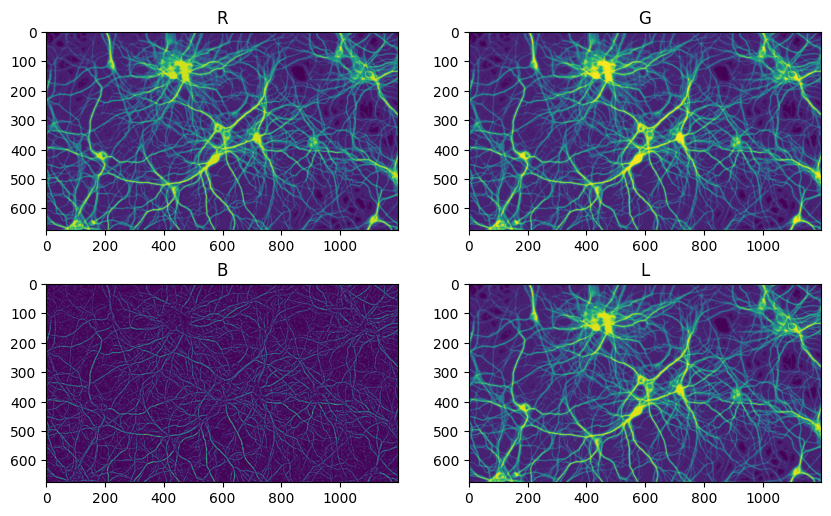

In [6]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 6))
axs = axs.flatten()

ax = axs[0]
ax.imshow(R)
ax.set_title("R")

ax = axs[1]
ax.imshow(G)
ax.set_title("G")

ax = axs[2]
ax.imshow(B)
ax.set_title("B")

ax = axs[3]
ax.imshow(L)
ax.set_title("L")

plt.show()

## Initialisation

### Generate Sample

In [7]:
sample = sqrt(L / L.max()) * np.exp(1j * TAU * (B / B.max()))
Nys, Nxs = sample.shape

nxs = np.arange(Nxs)
nys = np.arange(Nys)
dkxs = TAU / Nxs
dkys = TAU / Nys
kxs = (nxs - Nxs // 2) * dkxs
kys = (nys - Nys // 2) * dkys

shift = lambda E, dx, dy: f2s(s2f(E) * np.exp(-1j * (col(dy * kys) + row(dx * kxs))))

### Generate Measurement Co-ordinates

In [8]:
Nm = 1 << 8
nm = np.arange(Nm)
dkm = TAU / Nm
km = (nm - Nm // 2) * dkm

mask = lambda E: E[:Nm, :Nm]
prop = lambda E, L: f2s(s2f(E) * np.exp(-1j * (col(km)**2 + row(km)**2)*L))


### Generate Probe

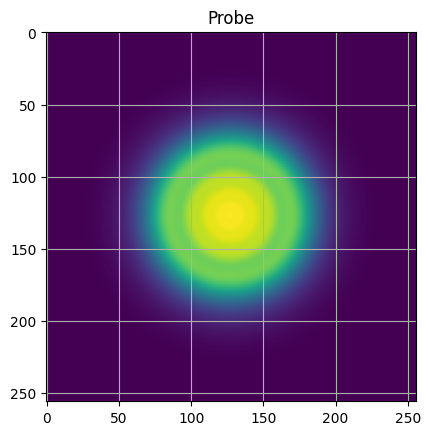

In [9]:
# Initial probe
r2 = col(nm-Nm//2+1)**2 + row(nm-Nm//2+1)**2
r = sqrt(r2)
probe = gauss1d(r, 0, Nm*.5, 1)

# Mask probe
probe *= gauss1d(r, 0, Nm*.5, 10)

# Propagate probe
probe = prop(probe, 40)

# Filter probe
probe *= gauss1d(r, 0, Nm*.75, 5)

plt.imshow((abs(probe)))
plt.grid()
plt.title("Probe")
plt.show()

### Generate Probe Positions

In [10]:
overlap = 0.66
offset = 0.0
Nxp = int((Nxs / Nm) / (1 - overlap))
Nyp = int((Nys / Nm) / (1 - overlap))
dxp = Nxs/(Nxp+1+1/overlap)
dyp = Nys/(Nyp+1+1/overlap)
xp = np.random.normal((np.arange(Nxp))*dxp, offset*dxp)
yp = np.random.normal((np.arange(Nyp))*dyp, offset*dyp)

print(f"{Nxp=}, {Nyp=}\n{dxp=}, {dyp=}")

Nxp=13, Nyp=7
dxp=77.279296875, dyp=70.93949044585987


### Generate Scattergrams

In [11]:
ind = np.array([(ny, nx) for ny in range(Nyp) for nx in range(Nxp)])
near_field = np.array([mask(shift(sample, -xp[nx], -yp[ny])) * probe for ny in range(Nyp) for nx in range(Nxp)])
far_field = abs2(s2f(near_field))

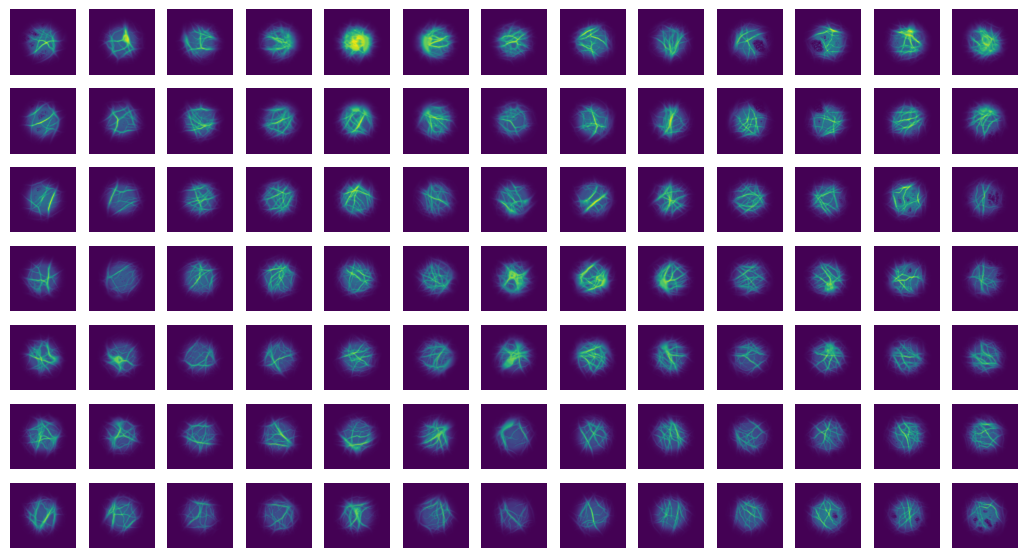

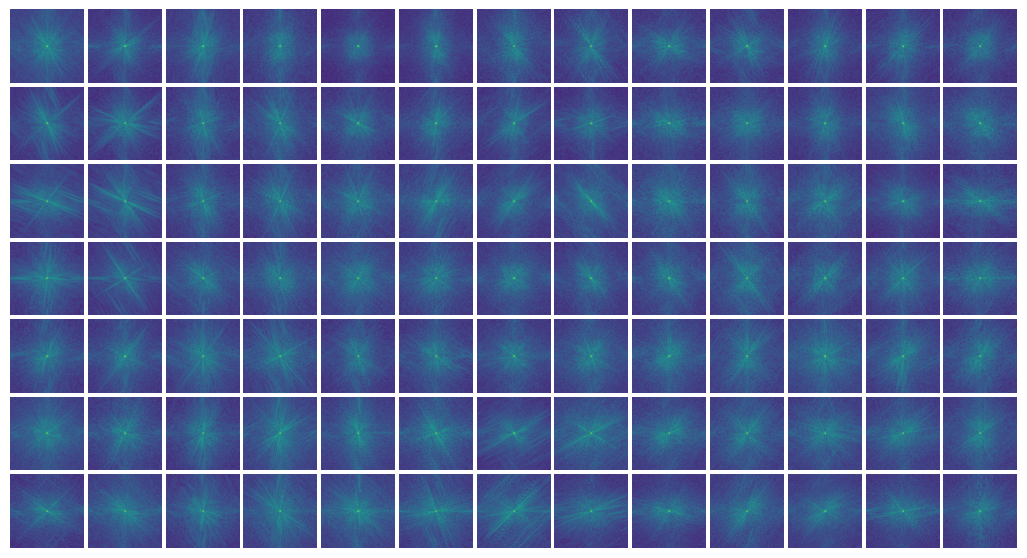

In [12]:
fig1, axs1 = plt.subplots(nrows=Nyp, ncols=Nxp, figsize=(Nxp, Nyp))
fig2, axs2 = plt.subplots(nrows=Nyp, ncols=Nxp, figsize=(Nxp, Nyp))

for ny in range(Nyp):
    for nx in range(Nxp):
        ax1 = axs1[ny, nx]
        ax2 = axs2[ny, nx]
        n = np.ravel_multi_index((ny, nx), (Nyp, Nxp))
        ax1.imshow(abs(near_field[n]))
        ax2.imshow(far_field[n]**.1)
        ax1.axis("off")
        ax2.axis("off")

plt.subplots_adjust(wspace=0.05, hspace=0.05)  # Adjust spacing
plt.show()

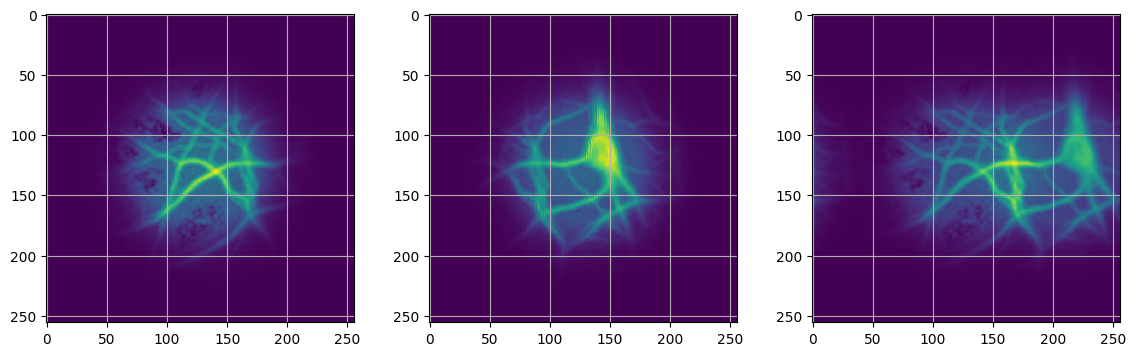

In [13]:
fig, axs = plt.subplots(ncols=3, figsize=(14, 4))

ax = axs[0]
ax.imshow(abs(near_field[0]))
ax.grid()

ax = axs[1]
ax.imshow(abs(near_field[1]))
ax.grid()

ax = axs[2]
ax.imshow(abs(near_field[0]) + abs(f2s(s2f(near_field[1]) * exp(-1j*row(km*(xp[1]-xp[0]))))))
ax.grid()

plt.show()

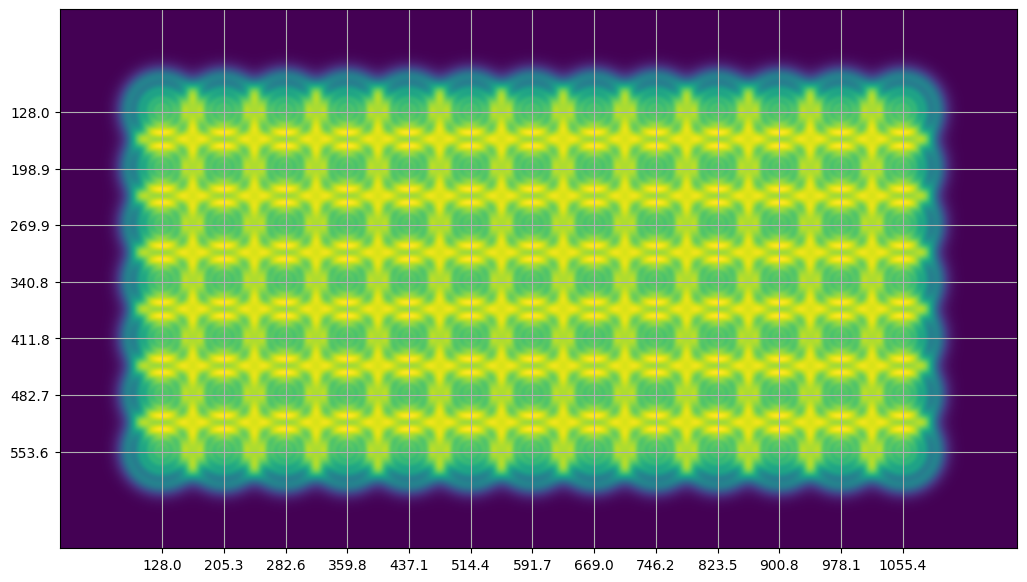

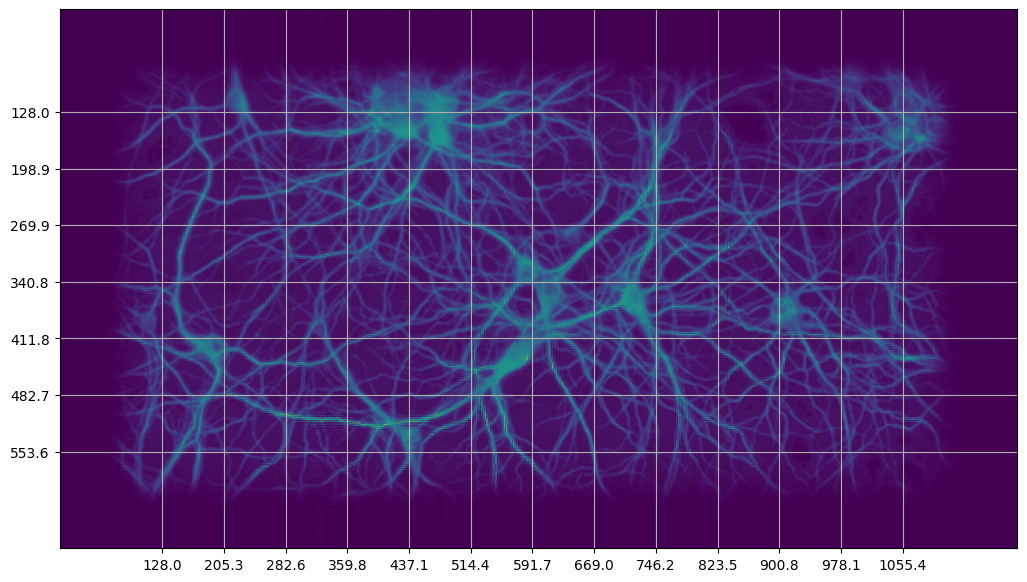

In [14]:
recon = 0*abs(sample)
recon1 = 0*abs(sample)

# recon[:Nm, :Nm] += abs2(probe)
for ny in range(Nyp):
    for nx in range(Nxp):
        n = np.ravel_multi_index((ny, nx), (Nyp, Nxp))
        
        recon = shift(recon, -xp[nx], -yp[ny])
        recon[:Nm, :Nm] += abs2(probe)
        recon = shift(recon, xp[nx], yp[ny])
        
        recon1 = shift(recon1, -xp[nx], -yp[ny])
        recon1[:Nm, :Nm] += abs2(near_field[n])
        recon1 = shift(recon1, xp[nx], yp[ny])

fig = plt.subplots(figsize=(Nxp, Nyp))
plt.imshow(abs(recon))
plt.grid()
plt.xticks(xp+Nm/2)
plt.yticks(yp+Nm/2)
plt.show()

fig = plt.subplots(figsize=(Nxp, Nyp))
plt.imshow(abs(recon1))
plt.grid()
plt.xticks(xp+Nm/2)
plt.yticks(yp+Nm/2)
plt.show()